In [1]:
pip install osmnx geopandas matplotlib contextily

Note: you may need to restart the kernel to use updated packages.


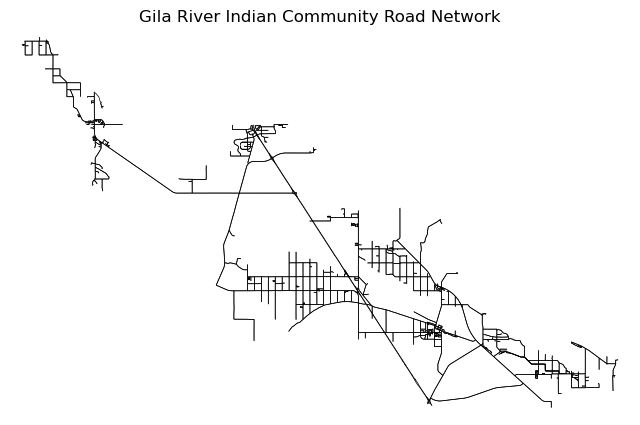

In [2]:
import osmnx as ox
import matplotlib.pyplot as plt

place = "Gila River Indian Community, Arizona, USA"

# Download road network
G = ox.graph_from_place(place, network_type="drive")

# Plot
fig, ax = ox.plot_graph(
    G,
    bgcolor="white",
    node_size=0,
    edge_color="black",
    edge_linewidth=0.5,
    show=False,
    close=False
)

plt.title("Gila River Indian Community Road Network")
plt.show()

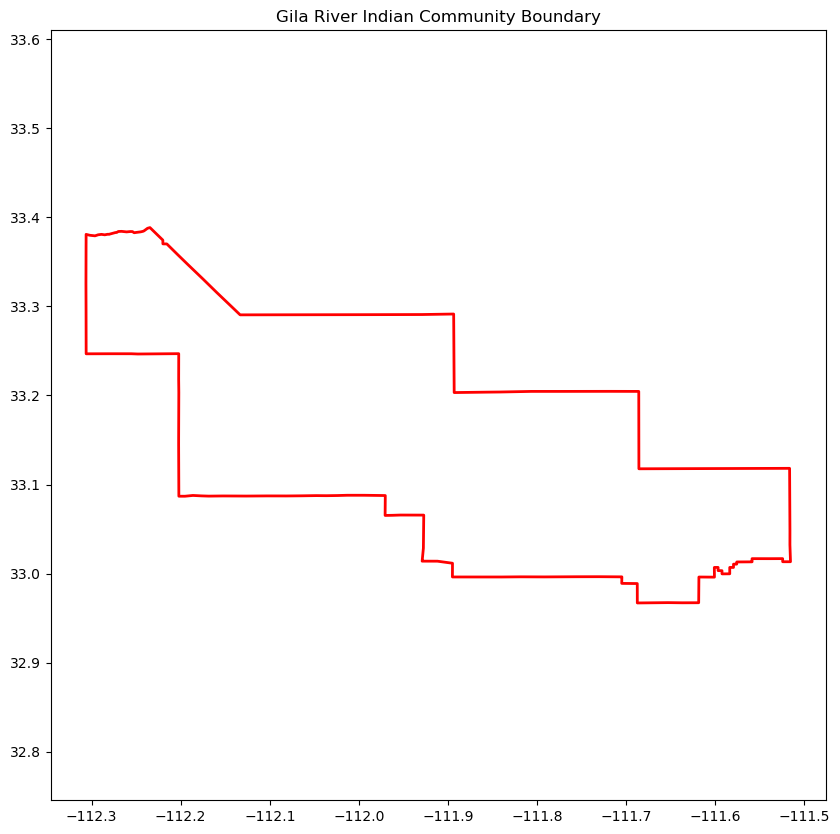

In [3]:
import osmnx as ox
import matplotlib.pyplot as plt

place = "Gila River Indian Community, Arizona, USA"

# Boundary polygon
boundary = ox.geocode_to_gdf(place)

fig, ax = plt.subplots(figsize=(10, 10))

boundary.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2
)

plt.title("Gila River Indian Community Boundary")
plt.axis("equal")
plt.show()

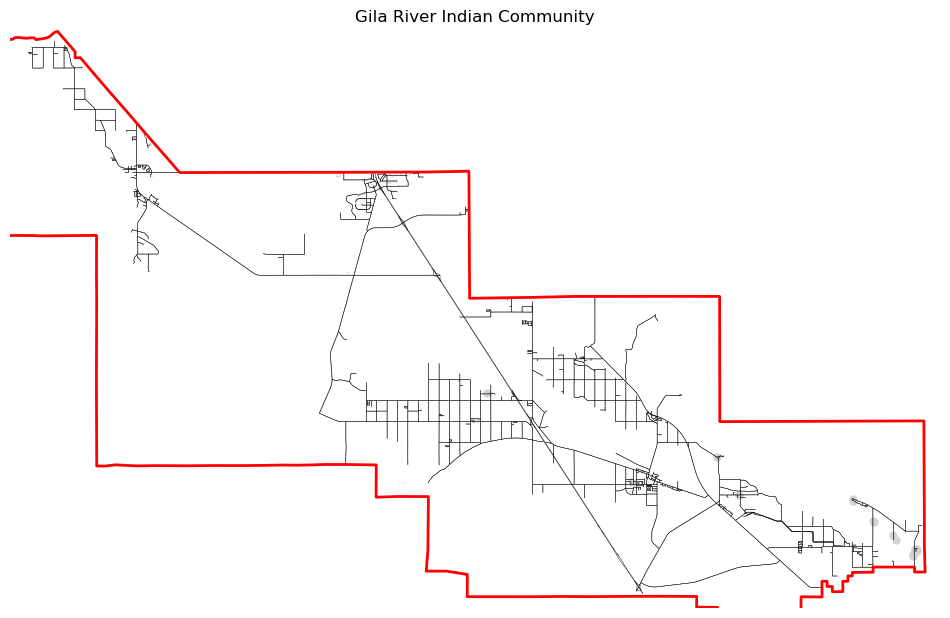

In [4]:
import osmnx as ox
import matplotlib.pyplot as plt

place = "Gila River Indian Community, Arizona, USA"

boundary = ox.geocode_to_gdf(place)

tags = {"building": True}
buildings = ox.features_from_place(place, tags)

G = ox.graph_from_place(place, network_type="drive")

fig, ax = plt.subplots(figsize=(12,12))

# Buildings
buildings.plot(
    ax=ax,
    color="lightgray",
    linewidth=0
)

# Roads
ox.plot_graph(
    G,
    ax=ax,
    node_size=0,
    edge_color="black",
    edge_linewidth=0.3,
    show=False,
    close=False
)

# Boundary
boundary.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2
)

plt.title("Gila River Indian Community")
plt.axis("off")
plt.show()

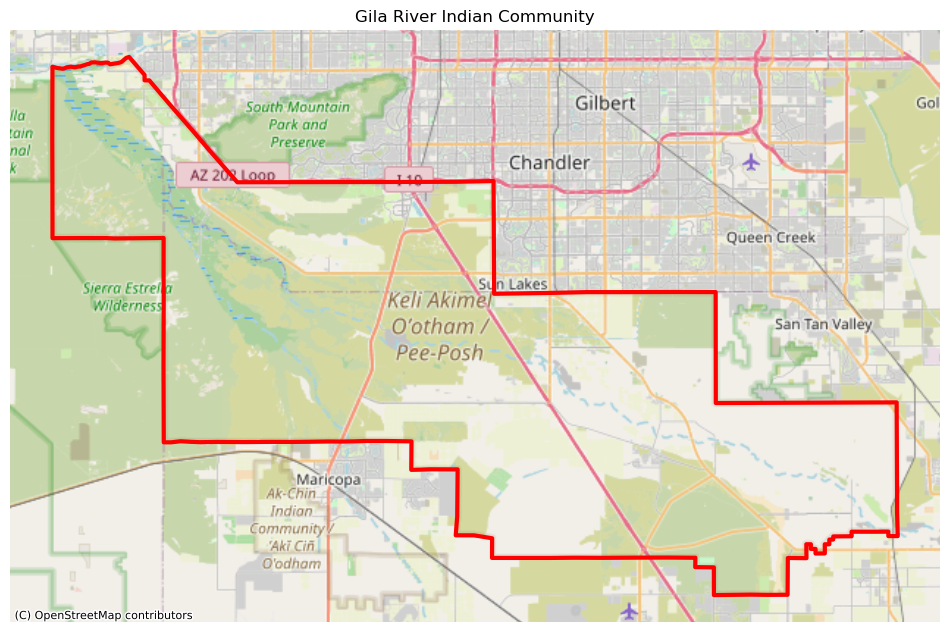

In [5]:
import osmnx as ox
import contextily as ctx
import matplotlib.pyplot as plt

place = "Gila River Indian Community, Arizona, USA"

boundary = ox.geocode_to_gdf(place)

# Convert to Web Mercator
boundary = boundary.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12,10))

boundary.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=3
)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

plt.title("Gila River Indian Community")
plt.axis("off")
plt.show()

In [6]:
import geopandas as gpd
import pandas as pd

import hvplot.pandas
import hvplot.xarray

from holoviews import opts

In [7]:
import osmnx as ox
import geopandas as gpd

In [8]:
gric = ox.geocode_to_gdf(
    "Gila River Indian Community, Arizona, USA"
)

gric.head()

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-112.30629 33.32529, -112.30617 33.2...",-112.306291,32.967088,-111.515615,33.388326,332995353,relation,10731873,33.177729,-111.944008,boundary,aboriginal_lands,25,0.066717,aboriginal_lands,Gila River Indian Community,"Gila River Indian Community, Pinal County, Ari..."


<Axes: >

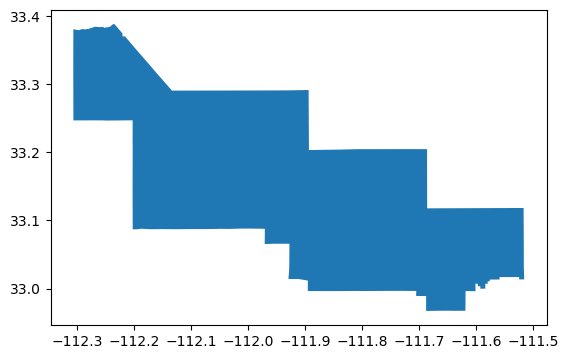

In [9]:
gric.plot()

In [11]:
gric.to_file("gric_boundary.shp")
boundary_gdf = gpd.read_file("gric_boundary.shp")

/tmp/ipykernel_9834/2165521529.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gric.to_file("gric_boundary.shp")
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'addresstype' to 'addresstyp'
  ogr_write(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'display_name' to 'display_na'
  ogr_write(


In [14]:
boundary_gdf.head()
boundary_gdf.columns
boundary_gdf.hvplot(
    geo=True,
    tiles="EsriImagery",
    fill_color=None,
    line_color="yellow",
    line_width=3,
    frame_width=700,
    title="Gila River Indian Community"
)

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

In [15]:
import osmnx as ox

In [16]:
roads = ox.features_from_place(
    "Gila River Indian Community, Arizona, USA",
    tags={"highway": True}
)

In [17]:
roads.head()

geometry            highway  ref source  \
element id                                                                     
node    41201438   POINT (-111.96739 33.2837)     turning_circle  NaN    NaN   
        41260760  POINT (-111.91642 33.21465)  motorway_junction  167    NaN   
        41260762  POINT (-111.91756 33.21923)    traffic_signals  NaN   Bing   
        41286594   POINT (-111.9228 33.21924)    traffic_signals  NaN   Bing   
        41289407  POINT (-112.21426 33.36372)     turning_circle  NaN    NaN   

                 traffic_signals traffic_signals:direction note  \
element id                                                        
node    41201438             NaN                       NaN  NaN   
        41260760             NaN                       NaN  NaN   
        41260762  traffic_lights                      both  NaN   
        41286594  traffic_lights                      both  NaN   
        41289407             NaN                       NaN  NaN   

                 turning_circle bicycle crossing  ... footway emergency  \
element id                                        ...                     
node    41201438            NaN     NaN      NaN  ...     NaN       NaN   
        41260760            NaN     NaN      NaN  ...     NaN       NaN   
        41260762            NaN     NaN      NaN  ...     NaN       NaN   
        41286594            NaN     NaN      NaN  ...     NaN       NaN   
        41289407            NaN     NaN      NaN  ...     NaN       NaN   

                 informal tactile_paving area construction change:lanes  \
element id                                                                
node    41201438      NaN            NaN  NaN          NaN          NaN   
        41260760      NaN            NaN  NaN          NaN          NaN   
        41260762      NaN            NaN  NaN          NaN          NaN   
        41286594      NaN            NaN  NaN          NaN          NaN   
        41289407      NaN            NaN  NaN          NaN          NaN   

                 name:full name:prefix proposed  
element id                                       
node    41201438       NaN         NaN      NaN  
        41260760       NaN         NaN      NaN  
        41260762       NaN         NaN      NaN  
        41286594       NaN         NaN      NaN  
        41289407       NaN         NaN      NaN  

[5 rows x 136 columns]

In [18]:
roads = roads[
    roads.geometry.type.isin(
        ["LineString", "MultiLineString"]
    )
]

In [19]:
roads.hvplot(
    geo=True,
    color="white",
    line_width=1,
    tiles="EsriImagery"
)

:Overlay
   .WMTS.I :WMTS   [Longitude,Latitude]
   .Path.I :Path   [Longitude,Latitude]

In [23]:
boundary_map = boundary_gdf.hvplot(
    geo=True,
    tiles="EsriImagery",
    fill_color=None,
    line_color="yellow",
    line_width=3
)

road_map = roads.hvplot(
    geo=True,
    color="cyan",
    line_width=1
)

boundary_map * road_map

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]
   .Path.I     :Path   [Longitude,Latitude]

In [26]:
%store boundary_gdf roads gric

Stored 'boundary_gdf' (GeoDataFrame)
Stored 'roads' (GeoDataFrame)
Stored 'gric' (GeoDataFrame)
